# Validación rápida: ganancia activa/pasiva (gato) vs. Neely & Kim (1986)

Comprueba que `CAT_PARAMS` reproduce las cifras de ganancia que da el paper en la Fig. 8 / Sec. III: **24 dB a 0.4 kHz** y **63 dB a 6.4 kHz**.

In [1]:
from cochleasim.models.params_loader import CAT_PARAMS
from cochleasim.analysis.response import gain_active_vs_passive

In [2]:
for f_hz, ref_db in [(400, 24), (6400, 63)]:
    gain = gain_active_vs_passive(CAT_PARAMS, f_hz, N=1000).gain_db_at_cf
    print(f"{f_hz:>5} Hz -> modelo: {gain:5.1f} dB   |   paper: {ref_db} dB")

  400 Hz -> modelo:  24.4 dB   |   paper: 24 dB
 6400 Hz -> modelo:  63.0 dB   |   paper: 63 dB


### Perfil espacial completo
`GainProfile` también da la curva de ganancia en función de la posición, no solo el valor en el CF (equivalente a la Fig. 8 del paper).

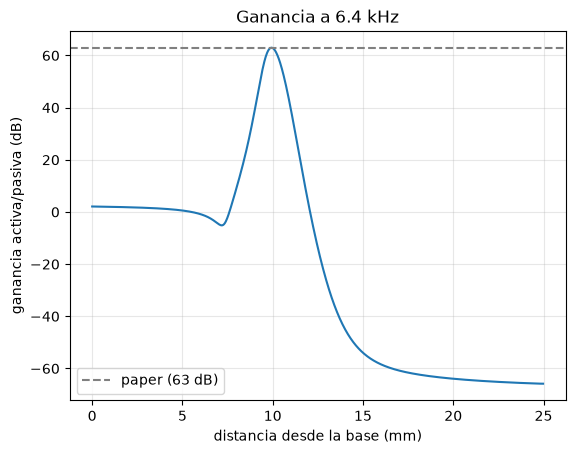

In [3]:
import matplotlib.pyplot as plt

gp = gain_active_vs_passive(CAT_PARAMS, 6400, N=1000)
plt.plot(gp.x_cm * 10, gp.gain_db)
plt.axhline(63, color='gray', linestyle='--', label='paper (63 dB)')
plt.xlabel('distancia desde la base (mm)')
plt.ylabel('ganancia activa/pasiva (dB)')
plt.title('Ganancia a 6.4 kHz')
plt.legend()
plt.grid(alpha=0.3)
plt.show()